# Myeloid differential marker expression analysis (DEA)

In [1]:
library_load <- suppressMessages(
    
    suppressWarnings(
    
            list(
                
                # Seurat 
                library(Seurat), 

                # Parallel 
                library(future), 

                # GSEA 
                library(msigdbr), 
                library(fgsea), 

                # Data 
                library(tidyverse), 
                library(openxlsx), 

                # Plotting 
                library(ComplexHeatmap), 
                library(circlize), 
                library(viridis), 
                library(ggplotify), 
                library(patchwork), 
                library(RColorBrewer), 

                # Python 
                library(reticulate)
            
            )
    )
)

In [2]:
# Configure reticulate 
use_condaenv(condaenv='p.3.8.12-FD20220623HSCT', conda="/nobackup/peer/fdeckert/miniconda3/bin/conda", required=NULL)
py_config()

python:         /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT/bin/python
libpython:      /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT/lib/libpython3.8.so
pythonhome:     /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT:/nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT
version:        3.8.12 | packaged by conda-forge | (default, Jan 30 2022, 23:42:07)  [GCC 9.4.0]
numpy:          /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT/lib/python3.8/site-packages/numpy
numpy_version:  1.22.4

NOTE: Python version was forced by use_python() function

In [3]:
options(warn=-1)
options(dplyr.summarise.inform = FALSE)

In [4]:
random_seed <- 42
set.seed(random_seed)

In [5]:
# Set working directory to project root
setwd("/research/peer/fdeckert/FD20220623HSCT")

In [6]:
# Source files
source("plotting_global.R")
source("bin/seurat_qc.R")
source("bin/gsea.R")

In [7]:
# Plotting Theme
ggplot2::theme_set(theme_global_set(size_select=1)) # From project global source()

# Import Seurat object

In [8]:
so <- readRDS("data/object/subsets/annotation/myeloid.rds")

# UMAP

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


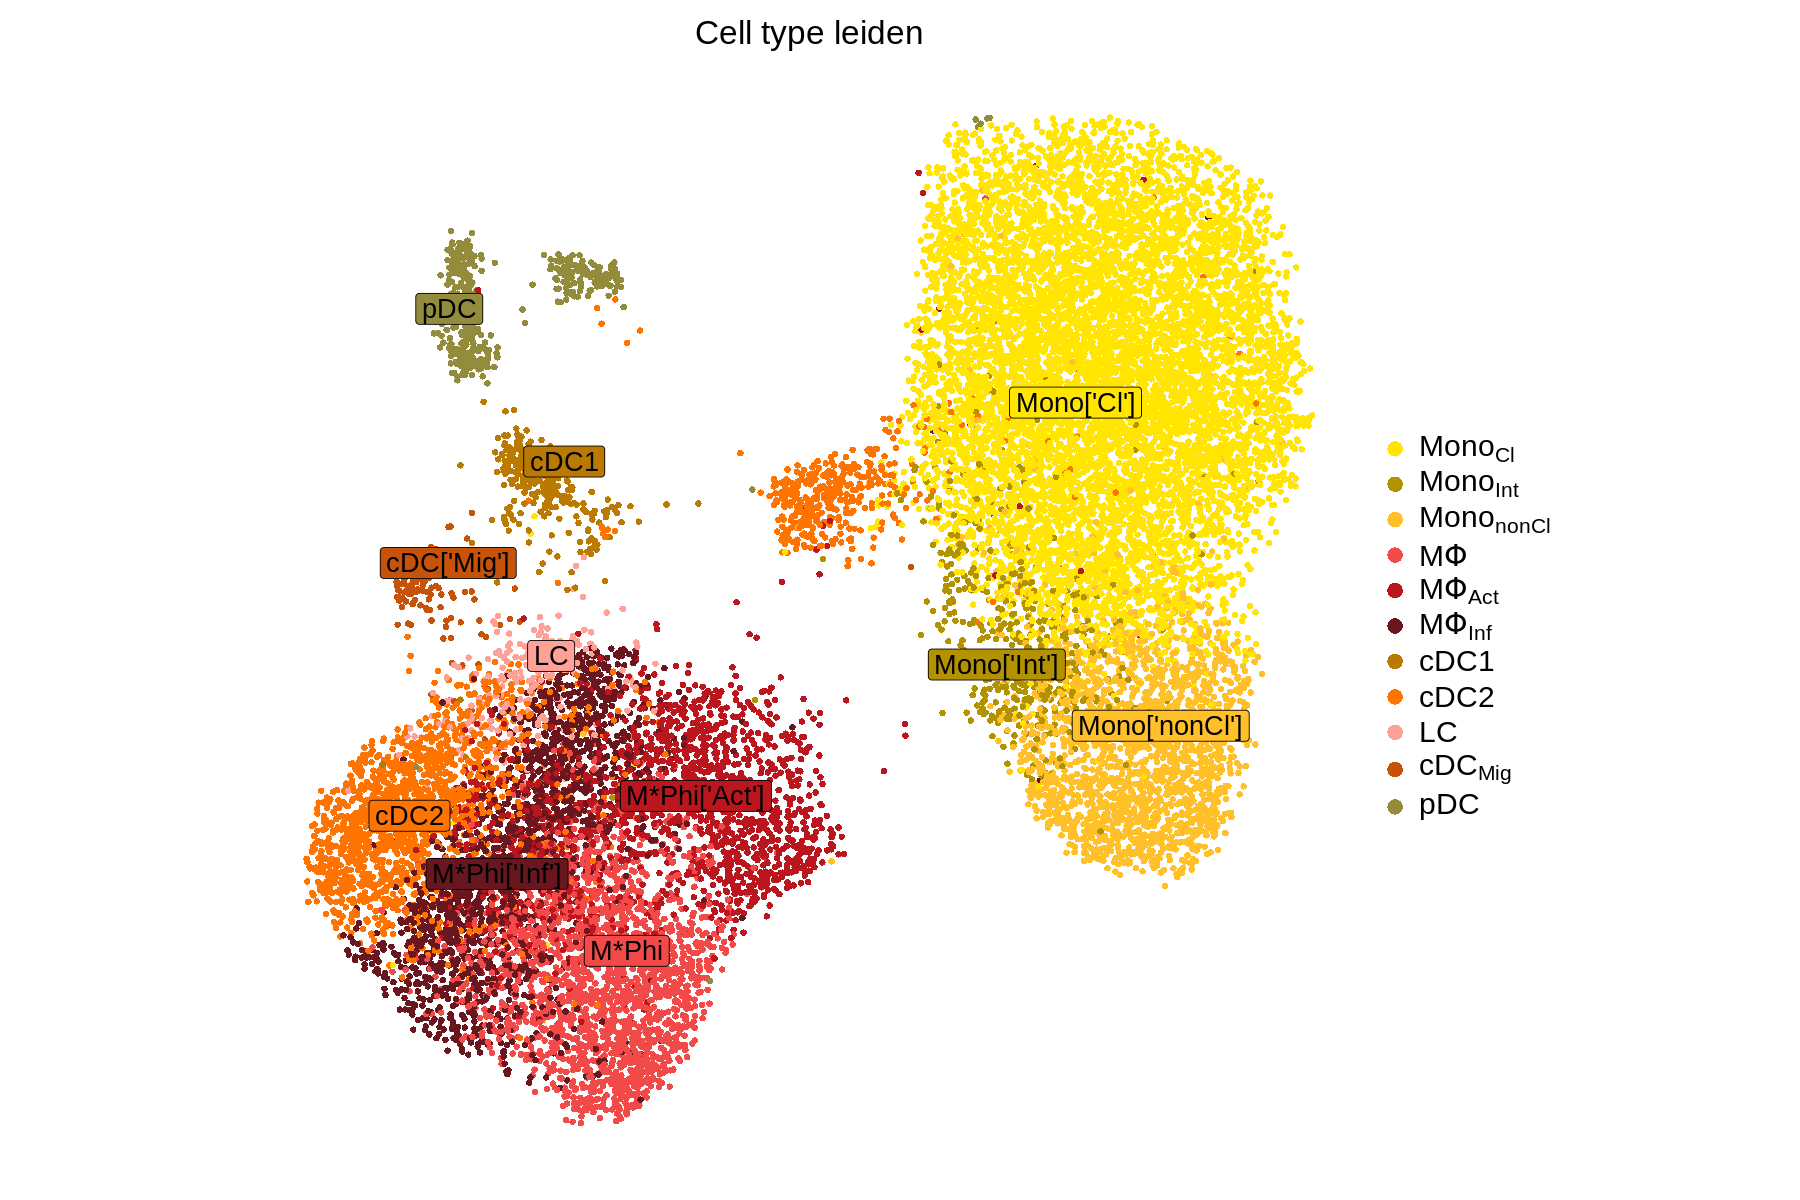

In [9]:
options(repr.plot.width=15, repr.plot.height=10)

dplot_1 <- dplot(so, reduction="umap", group_by="leiden_cell_type_main", alpha=1, pt_size=1.5, label=TRUE, label_size=16, label_box=TRUE) + ggtitle("Cell type leiden") + 
    scale_color_manual(values=color$cell_type_leiden_subset_r, labels=base::str2expression(levels(so$leiden_cell_type_main))) + 
    scale_fill_manual(values=color$cell_type_leiden_subset_r, labels=base::str2expression(levels(so$leiden_cell_type_main))) + 
    theme(legend.text.align=0) 

dplot_1

# Set DEA parameter

In [10]:
grouping_var="leiden_cell_type_main"
pseudobatch_var="patient_id"

p_adj_thr=0.05
sample_weights=TRUE

In [11]:
voom_lm_fit <- function(grouping_var_i, so, grouping_var, pseudobatch_var, sample_weights) {
    
    # Get relevant genes for grouping_var 
    cnt <- GetAssayData(so, assay="RNA", slot="counts")
    cnt <- cnt[, so[[grouping_var, drop=TRUE]]==grouping_var_i]
    cnt <- cnt[rowSums(cnt>3)>3, ]
    genes_i <- rownames(cnt)
    
    # Get Counts 
    cnt <- GetAssayData(so, assay="RNA", slot="counts")
    
    # Subset counts 
    cnt <- cnt[genes_i, ]
    
    # Prepare count data for split 
    cnt <- t(as.matrix(cnt))
    cnt <- as.data.frame(cnt)
        
    # Make pseudobulks by suming single cell counts
    cnt <- split(cnt, f=paste0(so[[grouping_var, drop=TRUE]], "|", so[[pseudobatch_var, drop=TRUE]]))
    cnt <- lapply(names(cnt), function(i) {x <- data.frame(counts=colSums(cnt[[i]])); colnames(x) <- i; return(x)})
    cnt <- do.call(cbind, cnt)
        
    # Get grouping variables from cnt matrix
    grouping_var_vec <- sapply(strsplit(colnames(cnt), "\\|"), `[[`, 1) # Used for design matrix
    pseudobatch_var_vec <- sapply(strsplit(colnames(cnt), "\\|"), `[[`, 2) # Used for design matrix
    
    # Design matrix 
    grouping_var_vec <- as.factor(grouping_var_vec)
    grouping_var_vec <- relevel(grouping_var_vec, ref=grouping_var_i)
    pseudobatch_var_vec <- as.character(pseudobatch_var_vec)
    design <- model.matrix(~0+grouping_var_vec)
    
    suppressMessages(
        
        fit <- edgeR::voomLmFit(

            counts=cnt, 
            design=design, 
            sample.weights=sample_weights, 
            var.design=design

        )
        
    )
    
    return(fit)
    
}

In [12]:
ebayes <- function(fit) {
    
    # Get grouping var and design from fit
    design <- fit$design
    
    # Define result list
    result <- list()
    
    # Grouping var vec 
    grouping_var_vec <- grep("grouping_var_vec", colnames(design), value=TRUE)
    grouping_var_ref <- grouping_var_vec[1]
    grouping_var_qry <- grouping_var_vec[-1]
    
    # Contrast fit
    contrasts_vec <- paste0(grouping_var_ref, "-(", paste0(grouping_var_qry, collapse="+"), ")/", length(grouping_var_qry))
    contrasts <- limma::makeContrasts(contrasts=contrasts_vec, levels=colnames(design))
    contrasts_fit <- limma::contrasts.fit(fit, contrasts=contrasts)

    # eBayes fit 
    efit <- limma::eBayes(contrasts_fit)

    # Get result table
    result_df <- limma::topTable(efit, sort.by="P", n=Inf, p.value=1, lfc=0, coef=1)

    # Convert results to Seurat format 
    colnames(result_df)[1] <- "avg_log2FC"
    colnames(result_df)[4] <- "p_value"
    colnames(result_df)[5] <- "p_val_adj"

    return(result_df)
    
}

In [13]:
dea_vp <- function(dea, log2fc_thr=1, p_adj_thr=0.05, top_label=10, title=NULL, color_neg=RColorBrewer::brewer.pal(8, "Set1")[1], color_pos=RColorBrewer::brewer.pal(8, "Set1")[2]) {

    # Set rownames to genes
    if("gene" %in% colnames(dea)) {rownames(dea) <- dea$gene}
    
    # Annotate entries significance by log2fc_thr and p_adj_thr
    dea$p_val_adj <- ifelse(dea$p_val_adj == 0, .Machine$double.xmin, dea$p_val_adj)
    dea$sig <- ifelse(abs(dea$avg_log2FC) >= log2fc_thr & -log10(dea$p_val_adj) >= -log10(p_adj_thr), "s", "ns")
    
    # Set color based on significance and direction of dea e.g. positive and negative 
    dea$color <- ifelse(dea$sig == "s" & dea$avg_log2FC > 0, "s_pos", "ns")
    dea$color <- ifelse(dea$sig == "s" & dea$avg_log2FC < 0, "s_neg", dea$color)
    
    color <- c(color_neg, "gray", "black", color_pos)
    names(color) <- c("s_pos", "ns", "black", "s_neg")
    
    # Create labels based log2FC and p_val_adj
    dea_pos <- dea[dea$avg_log2FC > 0 & dea$sig == "s", ]
    dea_neg <- dea[dea$avg_log2FC < 0 & dea$sig == "s", ]

    pos_labels_log2FC <- dea_pos[rev(order(dea_pos$avg_log2FC)), ][1:top_label, ] %>% rownames()
    neg_labels_log2FC <- dea_neg[order(dea_neg$avg_log2FC), ][1:top_label, ] %>% rownames()
    
    pos_labels_p_val_adj <- dea_pos[order(dea_pos$p_val_adj), ][1:top_label, ] %>% rownames()
    neg_labels_p_val_adj <- dea_neg[order(dea_neg$p_val_adj), ][1:top_label, ] %>% rownames()
    
    pos_labels <- c(pos_labels_log2FC, pos_labels_p_val_adj)
    neg_labels <- c(neg_labels_log2FC, neg_labels_p_val_adj)
    
    # Set labels 
    dea$label <- ifelse(rownames(dea) %in% c(pos_labels, neg_labels), rownames(dea), NA)

    # Plot
    vp <- ggplot(dea, aes(x=avg_log2FC, y=-log10(p_val_adj), fill=dea$color, label=label), alpha=1) + 
    
        geom_point(size=4, shape=21, color="white") + 
        geom_vline(aes(xintercept=log2fc_thr), linetype="dotted", colour="black") +
        geom_vline(aes(xintercept=-log2fc_thr), linetype="dotted", colour="black") +
        geom_hline(aes(yintercept=-log10(p_adj_thr)), linetype="dotted", colour="black") +
        ggrepel::geom_text_repel(segment.color="black", force=20, force_pull=1, max.overlaps=getOption("ggrepel.max.overlaps", default=100), size=5, alpha=1, guide="none", segment.size=0.1, color="black") + 
        xlim(-max(abs(dea$avg_log2FC)), max(abs(dea$avg_log2FC))) +  
        ylim(0, max(-log10(dea$p_val_adj))+1) + 
        ggtitle(base::str2expression(title)) + xlab("average log2FC") + ylab("-log10(adj. p-value)") + 
        scale_fill_manual(values=color) + 
    
        guides(
            
            color=guide_legend(order=1, title="Group", size=2, keywidth=0.75, keyheight=0.75), 
            alpha="none"
            
        ) + 
    
        theme(

            legend.position="none", 
            aspect.ratio=1

        )
    
    return(vp)
    
}

In [14]:
hm <- function(results, so, top=25) {
    
    # Get top genes
    genes <- lapply(results, function(x) dplyr::filter(x, sign(avg_log2FC)==1, p_val_adj<=0.01) %>% dplyr::mutate(pct_diff=pct_1-pct_2) %>% dplyr::arrange(-pct_diff, avg_log2FC, p_val_adj) %>% dplyr::slice(1:top) %>% rownames)

    # Get normalized data matrix
    so <- NormalizeData(so,   normalization.method="LogNormalize", scale.factor=10^6)
    mat <- GetAssayData(so, assay="RNA", slot="counts")
    
    # Filter matrix by genes and combine 
    mat <- lapply(genes, function(x) {mat[x, ]})                
    mat <- do.call(rbind, mat)
    mat <- as.matrix(mat)
    
    # Scale and order by column split
    mat <- t(scale(t(mat), center=TRUE, scale=TRUE))
    
    # Order mat columns 
    mat <- mat[, order(so$grouping_var_set)]
                    
    # Splits 
    column_split <- factor(so$grouping_var_set[order(so$grouping_var_set)], levels=names(results))
    row_split <- factor(rep(names(results), each=top), levels=names(results))
    
    # Color function 
    color_ramp_mat <- viridis::mako(10)
    breaks_mat <- seq(-2, 2, length.out=10)
    color_function_mat <- circlize::colorRamp2(breaks_mat, color_ramp_mat) 
                    
    hm <- ComplexHeatmap::Heatmap(
    
        matrix=mat, 

        col=color_function_mat, 
        na_col="white", 

        width=unit(200, "mm"), 
        height=unit(1*nrow(mat), "mm"), 

        row_title="Cell type marker marker", 
        row_title_gp=gpar(fontsize=18, fontface="bold"), 

        # column_title=NULL, 
        column_title_rot=90, 
        column_title_gp=gpar(fontsize=18, fontface="bold"), 

        row_names_gp=gpar(fontsize=16, fontface="plain"), 
        column_names_gp=gpar(fontsize=18, fontface="plain"), 

        cluster_rows=TRUE, 
        cluster_row_slices=FALSE,
        show_row_dend=FALSE,  
        row_split=row_split, 
        row_gap=unit(2, "mm"),
        show_row_names=FALSE,
        row_names_side="left",

        cluster_columns=TRUE,
        cluster_column_slices=FALSE, 
        show_column_dend=FALSE, 
        column_split=column_split,
        column_gap=unit(2, "mm"), 
        show_column_names=FALSE, 

        top_annotation=NULL, 
        right_annotation=NULL, 

        rect_gp=gpar(col=NA, lwd=0, alpha=1), 

        heatmap_legend_param=list(title="NES", title_gp=gpar(fontsize=18, fontface="plain"), labels_gp=gpar(fontsize=16), legend_height=unit(5*6, "mm"), grid_width=unit(6, "mm")), 

        border=TRUE, 
        border_gp=gpar(col="black", lwd=unit(0.5, "mm")), 

        use_raster=FALSE
    
    )
        
    return(hm)
        
}

# Blood 

In [15]:
# Import 
so <- readRDS("data/object/subsets/annotation/myeloid.rds")

In [16]:
# Subset
so <- subset(so, subset=hto_demux_class=="Blood")

In [17]:
# Store original names for plotting 
so$grouping_var_set <- so[[grouping_var, drop=TRUE]]

In [18]:
# Set names 
so[[grouping_var]] <- make.names(so[[grouping_var, drop=TRUE]])

In [19]:
# DEA voom fit 
fit <- lapply(unique(so[[grouping_var, drop=TRUE]]), voom_lm_fit, so=so, grouping_var=grouping_var, pseudobatch_var=pseudobatch_var, sample_weights=sample_weights)

In [20]:
# Get results 
results <- lapply(fit, ebayes)

In [21]:
# Set original grouping names 
rename_df <- distinct(so@meta.data[, c(grouping_var, "grouping_var_set")])
rename_df[1] <- paste0("grouping_var_vec", rename_df[[1]])
rename_df <- rename_df[order(rename_df$grouping_var_set), ]

In [22]:
names(results) <- paste0("grouping_var_vec", unique(so[[grouping_var, drop=TRUE]]))
results <- results[rename_df[[1]]]
names(results) <- rename_df[[2]]

In [23]:
mat <- GetAssayData(so, assay="RNA", slot="counts")
mat_order <- so$grouping_var_set

In [24]:
results <- lapply(names(results), function(i, mat, mat_order) {
    
    x <- results[[i]]
    mat <- mat[rownames(x), ]
    mat <- mat>0
    x$pct_1<-rowSums(mat[, mat_order==i])/sum(mat_order==i)
    x$pct_2<-rowSums(mat[, mat_order!=i])/sum(mat_order!=i)

    return(x)

}, mat=mat, mat_order=mat_order)

In [25]:
names(results) <- rename_df[[2]]

In [26]:
# Write xlsx
openxlsx::write.xlsx(results, "result/dea/subsets/myeloind_blood_leiden_cell_type_main.xlsx", colNames=TRUE, rowNames=TRUE)

In [ ]:
options(repr.plot.width=5*8, repr.plot.height=1*8)

vp <- lapply(names(results), function(i) {dea_vp(results[[i]], title=i, log2fc_thr=0, p_adj_thr=p_adj_thr)})
wrap_plots(vp, ncol=5, nrow=1)

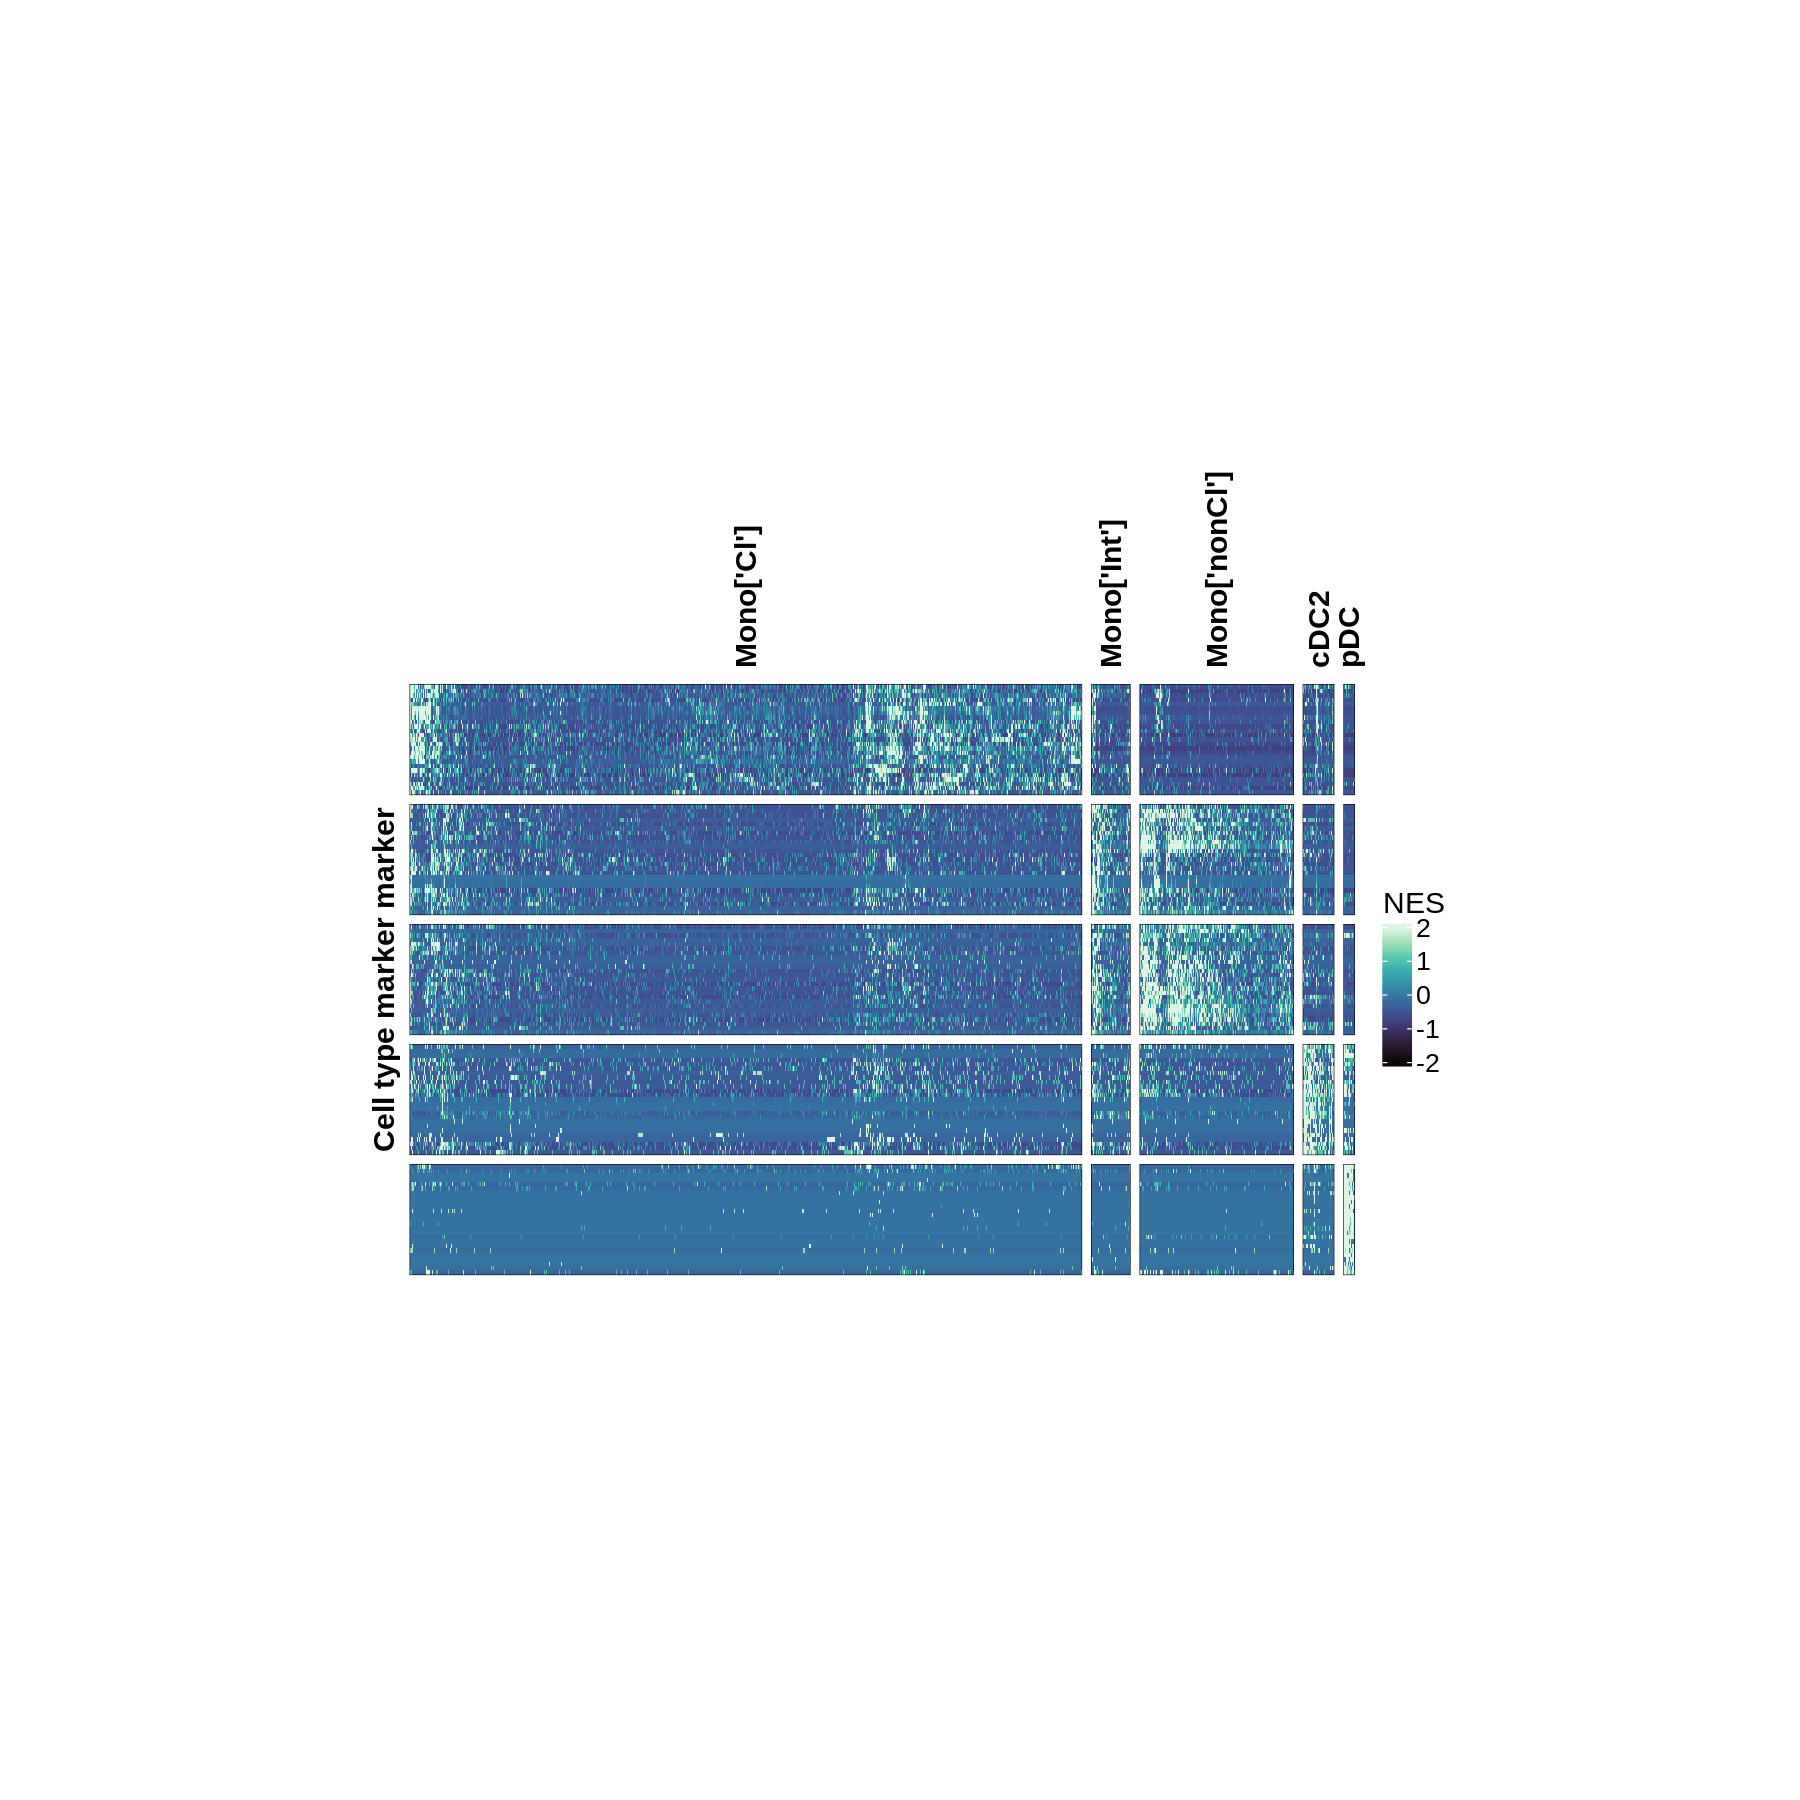

In [28]:
options(repr.plot.width=15, repr.plot.height=15)

hm(results, so, top=25)

# Skin 

In [29]:
# Import 
so <- readRDS("data/object/subsets/annotation/myeloid.rds")

In [30]:
# Subset
so <- subset(so, subset=hto_demux_class=="Skin")

In [31]:
# Store original names for plotting 
so$grouping_var_set <- so[[grouping_var, drop=TRUE]]

In [32]:
# Set names 
so[[grouping_var]] <- make.names(so[[grouping_var, drop=TRUE]])

In [33]:
# DEA voom fit 
fit <- lapply(unique(so[[grouping_var, drop=TRUE]]), voom_lm_fit, so=so, grouping_var=grouping_var, pseudobatch_var=pseudobatch_var, sample_weights=sample_weights)

In [34]:
# Get results 
results <- lapply(fit, ebayes)

In [35]:
# Set original grouping names 
rename_df <- distinct(so@meta.data[, c(grouping_var, "grouping_var_set")])
rename_df[1] <- paste0("grouping_var_vec", rename_df[[1]])
rename_df <- rename_df[order(rename_df$grouping_var_set), ]

In [36]:
names(results) <- paste0("grouping_var_vec", unique(so[[grouping_var, drop=TRUE]]))
results <- results[rename_df[[1]]]
names(results) <- rename_df[[2]]

In [37]:
mat <- GetAssayData(so, assay="RNA", slot="counts")
mat_order <- so$grouping_var_set

In [38]:
results <- lapply(names(results), function(i, mat, mat_order) {
    
    x <- results[[i]]
    mat <- mat[rownames(x), ]
    mat <- mat>0
    x$pct_1<-rowSums(mat[, mat_order==i])/sum(mat_order==i)
    x$pct_2<-rowSums(mat[, mat_order!=i])/sum(mat_order!=i)

    return(x)

}, mat=mat, mat_order=mat_order)

In [39]:
names(results) <- rename_df[[2]]

In [40]:
# Write xlsx
openxlsx::write.xlsx(results, "result/dea/subsets/myeloid_skin_leiden_cell_type_main.xlsx", colNames=TRUE, rowNames=TRUE)

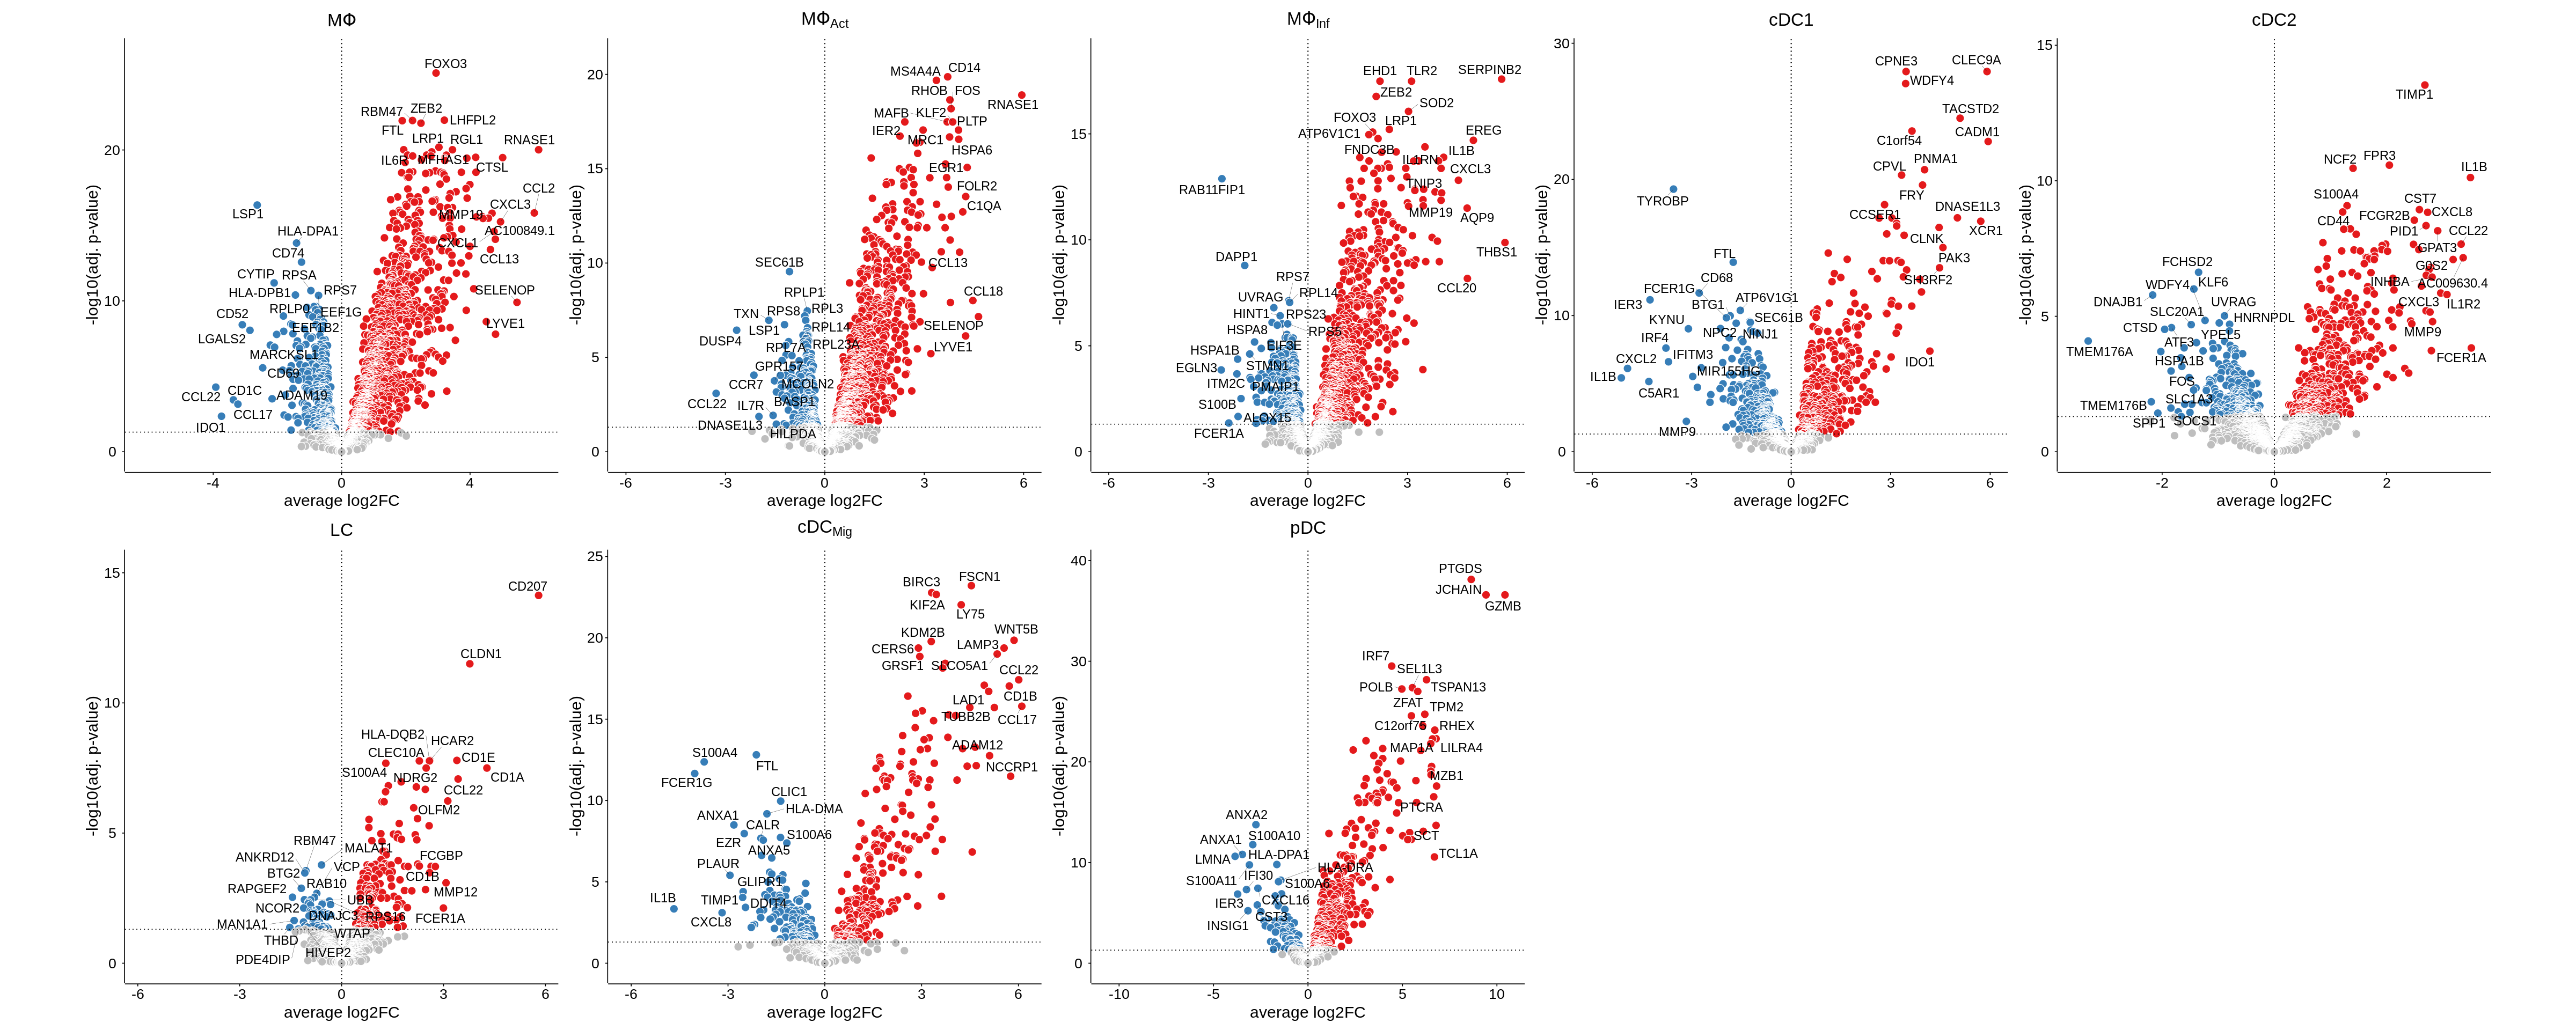

In [44]:
options(repr.plot.width=5*8, repr.plot.height=2*8)

vp <- lapply(names(results), function(i) {dea_vp(results[[i]], title=i, log2fc_thr=0, p_adj_thr=p_adj_thr)})
wrap_plots(vp, ncol=5, nrow=2)

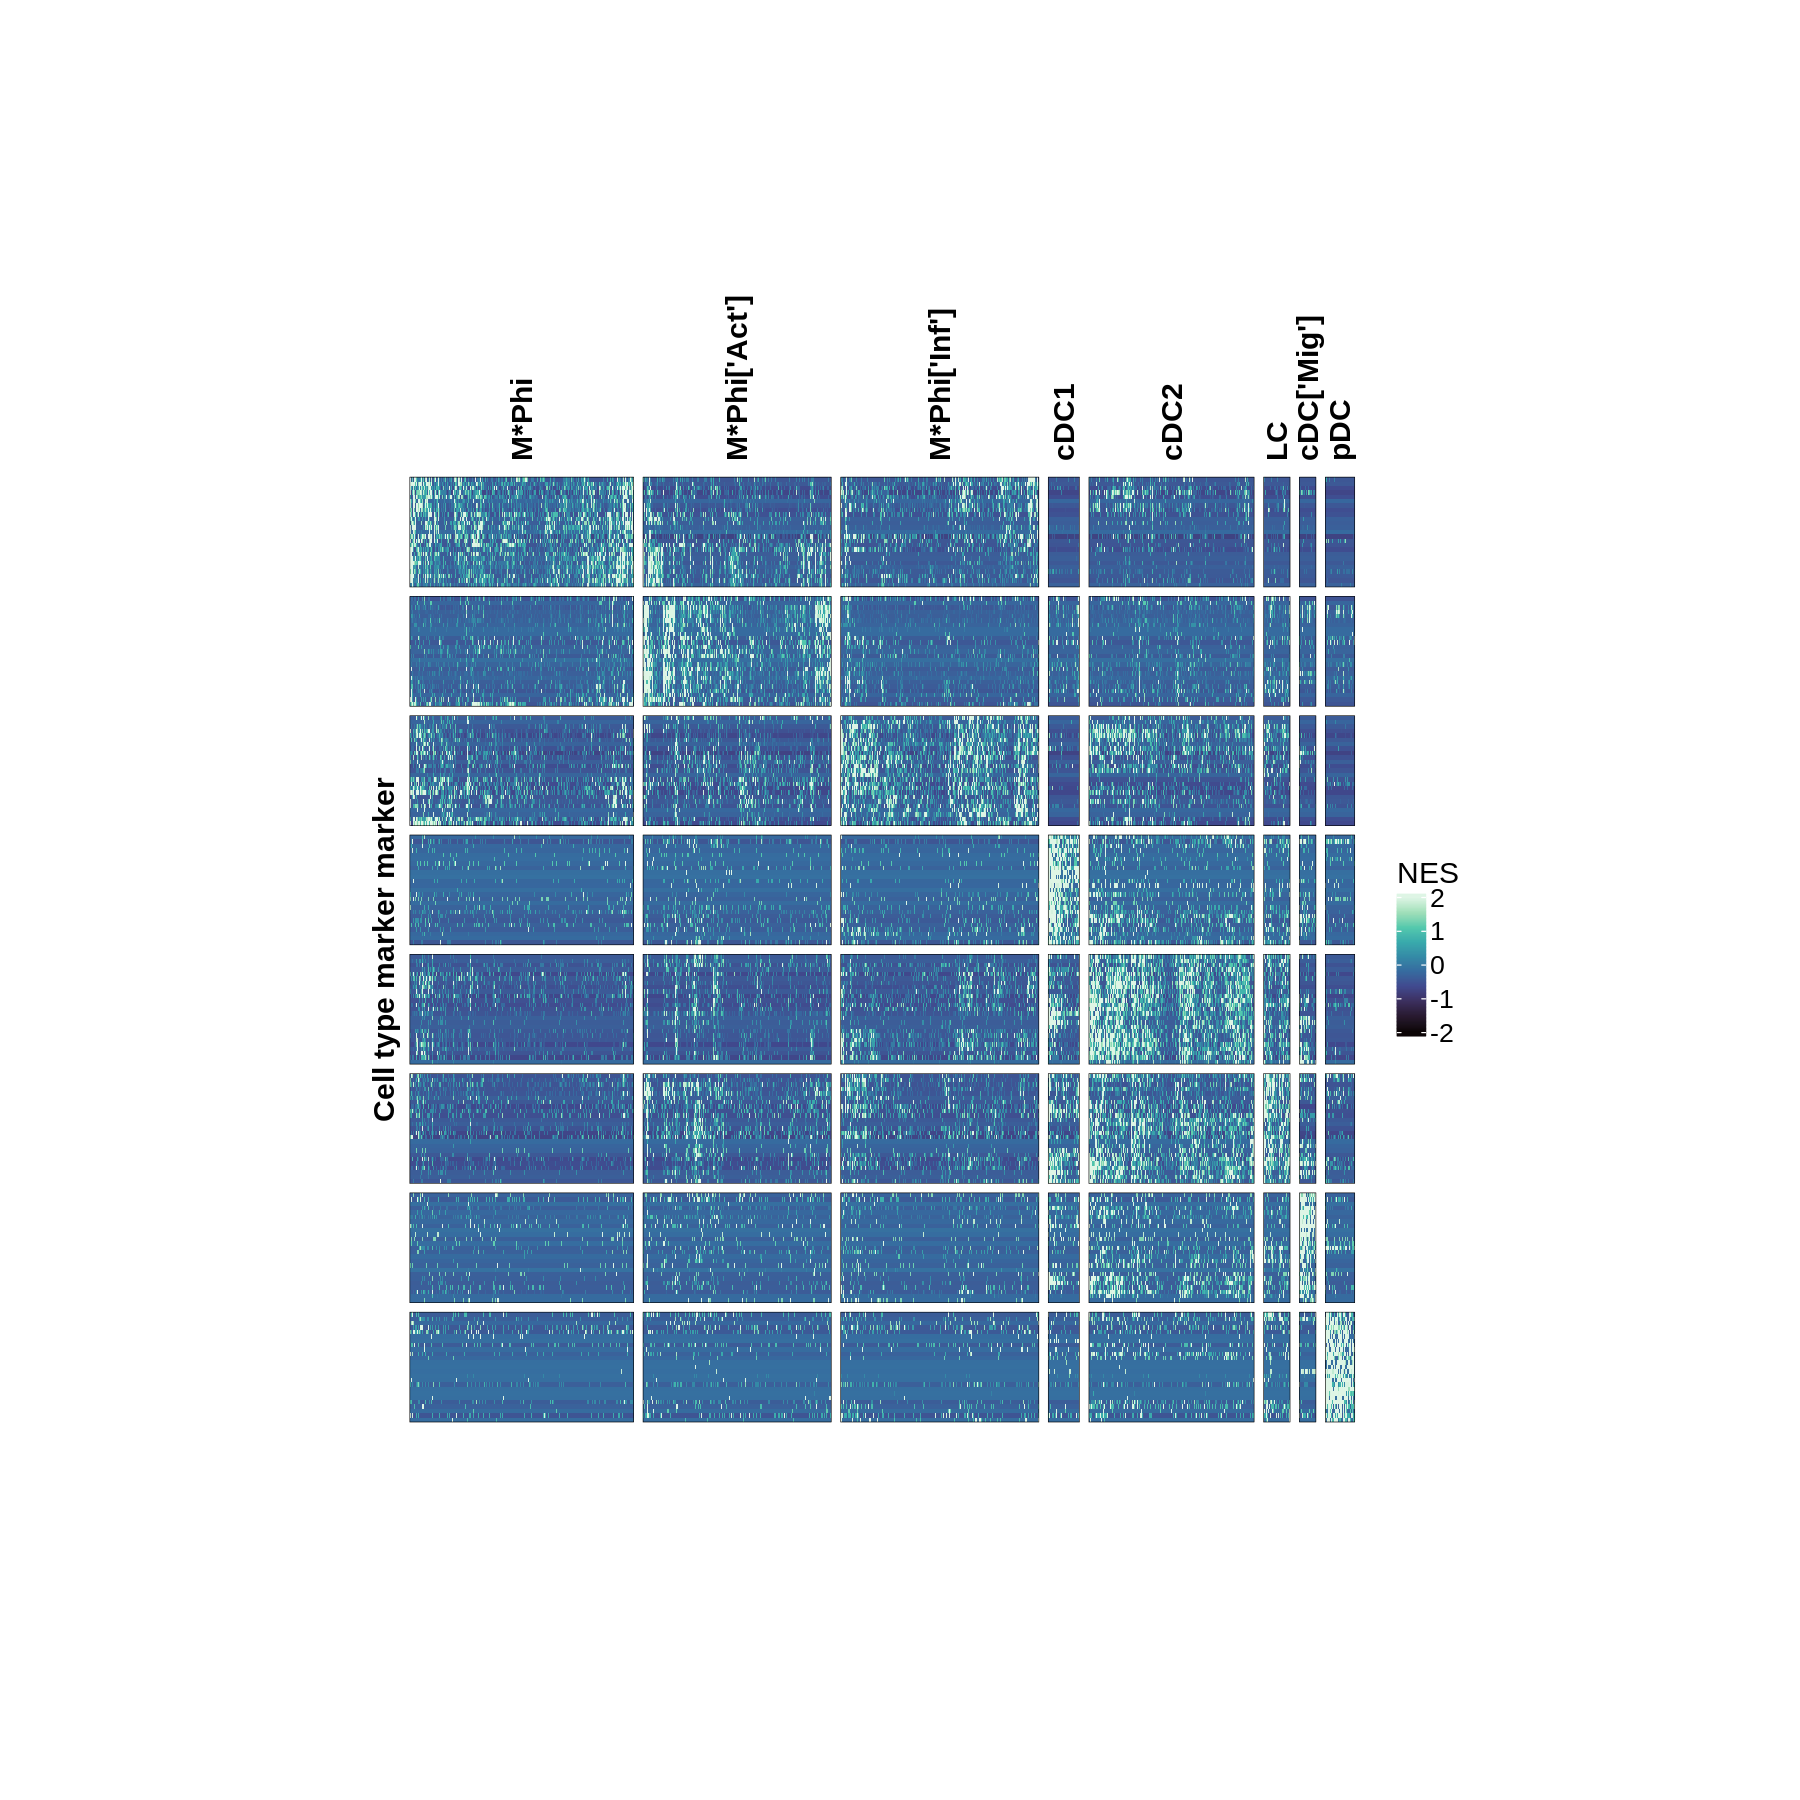

In [42]:
options(repr.plot.width=15, repr.plot.height=15)

hm(results, so, top=25)